In [1]:
from src.config import DATA_DIR

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap

# Set publication-quality defaults
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'font.size': 9,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
})

counts_df = pd.read_csv(f'{DATA_DIR}/metadata/atom_type_counts.csv')

types_list_1d = (
    counts_df.loc[
        (counts_df['local_reference_frame'] == 'Isotropic') &
        (counts_df['protein_count'] > 1000),
        'atom_type'
    ]
    .dropna()
    .unique()
    .tolist()
)

types_list_2d = (
    counts_df.loc[
        (counts_df['local_reference_frame'] == 'Axial') &
        (counts_df['protein_count'] > 1000),
        'atom_type'
    ]
    .dropna()
    .unique()
    .tolist()
)

types_list_3d = (
    counts_df.loc[
        (counts_df['local_reference_frame'] == 'Anisotropic') &
        (counts_df['protein_count'] > 1000),
        'atom_type'
    ]
    .dropna()
    .unique()
    .tolist()
)

ligand_types_list = (
    counts_df.loc[
        (counts_df['ligand_count'] > 500),
        'atom_type'
    ]
    .dropna()
    .unique()
    .tolist()
)

prot_types_list = types_list_1d + types_list_2d + types_list_3d

r_bins = np.arange(1.0, 6.0, 0.1)
theta_bins = np.arange(0, 90.0, 3.0)
phi_bins = np.arange(0, 180, 3.0)

loaded = np.load(f'{DATA_DIR}/potentials/despot_scores_crown_leaky.npz')
scores_1d = loaded['scores_1d'].astype(np.float32)
scores_2d = loaded['scores_2d'].astype(np.float32)
scores_3d = loaded['scores_3d'].astype(np.float32)

print(scores_1d.shape)
print(scores_2d.shape)
print(scores_3d.shape)

n_lat, n_lon = 60, 60
full_scores_1d = scores_1d[:, :, :, np.newaxis, np.newaxis] * np.ones((1, 1, 1, n_lat, n_lon), dtype = np.float32)
full_scores_2d = scores_2d[:, :, :, :, np.newaxis] * np.ones((1, 1, 1, 1, n_lon), dtype = np.float32)
full_scores_3d = np.concatenate([scores_3d, scores_3d[:, :, :, ::-1, :]], axis = 3)

del scores_1d, scores_2d, scores_3d

full_scores = np.concatenate([full_scores_1d, full_scores_2d, full_scores_3d], axis = 0)

print(full_scores.shape)
print(len(prot_types_list))
print(len(ligand_types_list))

del full_scores_1d, full_scores_2d, full_scores_3d

loaded = np.load(f'{DATA_DIR}/potentials/despot_ds_scores_crown_leaky.npz')
scores_isotropic = loaded['scores_1d'].astype(np.float32)

(9, 114, 50)
(39, 114, 50, 60)
(52, 114, 50, 30, 60)
(100, 114, 50, 60, 60)
100
114


In [2]:
def plot_anisotropy(p_type_list, l_type_list, distance_list):
    """
    Main function for plotting DESPOT pairwise interactions.

    Parameters
    ----------

    p_type_list [List[str]]: L protein types. See supplementary information for list of supported atom types
    l_type_list [List[str]]: L ligand types. See supplementary information for list of supported atom types
    distance_list [List[float]]: L distances, used to set the radius for the Mollweide projections. Value must be between 1 and 6.
    """

    cmap_custom = LinearSegmentedColormap.from_list(
        'blue_gray',
        [(0.0, "#023466"),   # strong blue at -5
        (0.5, '#ffffff'),   # white at 0
        (1.0, '#bfbbbb')]   # gray at +5
    )

    # E.g., if most values are 0–5 but negatives only go to -2
    norm = TwoSlopeNorm(vmin=-2.5, vcenter=0, vmax=5)

    L = len(p_type_list)
    fig = plt.figure(figsize=(3.5 * L, 10))

    gs = GridSpec(4, L, figure=fig, 
                  height_ratios=[2, 1.3, 1, 0.12],
                  wspace=0.4, hspace=0.3)
    fig.subplots_adjust(top=0.95, bottom=0.05, hspace=0.3)
    
    axes_top = [fig.add_subplot(gs[0,i], projection='mollweide') for i in range(L)]
    axes_mid = [fig.add_subplot(gs[1,i], projection='polar') for i in range(L)]
    axes_bottom = [fig.add_subplot(gs[2,i]) for i in range(L)]

    for ax in axes_mid:
        pos = ax.get_position()
        ax.set_position([pos.x0, pos.y0 + 0.1, pos.width, pos.height])  # nudge up by 0.04

    phi_bins_rad = np.deg2rad(phi_bins)
    theta_bins_rad = np.deg2rad(theta_bins)
    theta_full = np.concatenate([theta_bins_rad, np.pi - theta_bins_rad[::-1]])
    phi_full_moll = np.concatenate([2*np.pi - phi_bins_rad[::-1], phi_bins_rad])
    phi_full = np.concatenate([phi_bins_rad, 2*np.pi - phi_bins_rad[::-1]])
    R, PHI = np.meshgrid(r_bins, phi_full, indexing='ij')

    for i, (p_type, l_type, distance) in enumerate(zip(p_type_list, l_type_list, distance_list)):

        p_idx = prot_types_list.index(p_type)
        l_idx = ligand_types_list.index(l_type)
        r_idx = int(10*(distance - 1))
        subset = full_scores[p_idx, l_idx, r_idx, :, :]
        score_data = np.concatenate([subset[:, ::-1], subset], axis=1)

        theta_grid, phi_grid = np.meshgrid(theta_full, phi_full_moll, indexing='ij')
        lat = np.pi/2 - theta_grid
        lon = phi_grid.copy()
        lon[lon > np.pi] -= 2 * np.pi

        axes_top[i].pcolormesh(lon, lat, score_data, shading='auto', cmap=cmap_custom, norm = norm)
        axes_top[i].set_title(f'α: {p_type} - β: {l_type}', fontsize=11, pad=8)

        axes_top[i].text(1.05, -0.04, f'r = {distance} Å', transform=axes_top[i].transAxes, 
             fontsize=8, ha='right', va='bottom',
             bbox=dict(boxstyle='round,pad=0.2', facecolor='white', 
                      edgecolor='gray', alpha=0.8))
        
        axes_top[i].text(0, np.pi/2 * 0.87, 'θ=0°',   ha='center', va='top',    fontsize=7, color='black')
        axes_top[i].text(0, 0,               'θ=90°',  ha='center', va='center', fontsize=7, color='black')
        axes_top[i].text(0, -np.pi/2 * 0.87,'θ=180°', ha='center', va='bottom', fontsize=7, color='black')
        axes_top[i].text(np.pi * 0.92,       0, 'φ=180°',  ha='right',  va='center', fontsize=7, color='black')
        axes_top[i].text(-np.pi * 0.92,      0, 'φ=-180°', ha='left',   va='center', fontsize=7, color='black')

        axes_top[i].grid(True, linewidth=0.3, alpha=0.3)
        # Overdraw the equator
        axes_top[i].plot(np.linspace(-np.pi, np.pi, 200), np.zeros(200), 
            color='gray', lw=0.6, alpha=0.6, ls='--')
        
        # Remove cluttering tick labels, keep only grid
        axes_top[i].tick_params(labelsize=0, length=0)
        axes_top[i].grid(True, linewidth=0.3, alpha=0.5)

        # --- Middle plot ---
        axes_mid[i].set_theta_zero_location('N')
        axes_mid[i].set_theta_direction(-1)

        score_data = full_scores[p_idx, l_idx, :, 30, :] # theta = 90, azimuthal plane
        score_full = np.concatenate([score_data, score_data[:, ::-1]], axis=1)

        c = axes_mid[i].pcolormesh(PHI, R, score_full, shading='auto', cmap=cmap_custom, norm = norm)

        axes_mid[i].set_ylim(0, 6)
        axes_mid[i].set_yticks([2, 4, 6])
        axes_mid[i].set_yticklabels(['2', '4', '6'], fontsize=6)
        axes_mid[i].set_rlabel_position(45)
        axes_mid[i].set_xticks([0, np.pi/2, np.pi, 3*np.pi/2])
        axes_mid[i].set_xticklabels(['0°', '90°', '180°', '270°'], fontsize=7)
        axes_mid[i].tick_params(pad=2)
        axes_mid[i].text(1.15, -0.10, 'θ = 90°', transform=axes_mid[i].transAxes, 
             fontsize=8, ha='right', va='bottom',
             bbox=dict(boxstyle='round,pad=0.2', facecolor='white', 
                      edgecolor='gray', alpha=0.8))

        # --- Bottom plot ---
        score_data = scores_isotropic[p_idx, l_idx, :]
        axes_bottom[i].plot(r_bins, score_data, linewidth=1.5)
        axes_bottom[i].set_xlim(1, 6)
        axes_bottom[i].set_ylim(-2.5, 5)
        axes_bottom[i].axhline(0, color='gray', linestyle='--', linewidth=0.8)
        axes_bottom[i].tick_params(labelsize=8)

        # Only label outer axes
        if i == 0:
            axes_bottom[i].set_ylabel('Score', fontsize=10)
        else:
            axes_bottom[i].set_yticklabels([])
        axes_bottom[i].set_xlabel('Distance (Å)', fontsize=10)

    # ---- Colorbar ----
    cbar_ax = fig.add_subplot(gs[3, :])
    cbar = fig.colorbar(c, cax=cbar_ax, orientation='horizontal')
    cbar.set_label('Score', fontsize=11)
    cbar.ax.tick_params(labelsize=8)

    plt.show()

['O.h2o_0', 'C.1_2', 'P.o4_4', 'Mg', 'Fe', 'Zn', 'C.3r3x_4', 'Mn', 'Ca', 'C.am_3', 'C.3n_3', 'C.3c_1', 'C.3c_3', 'C.co2_3', 'O.3oh_1', 'C.ar6_3', 'C.oh_3', 'N.4_1', 'C.ar6x_3', 'C.3r5x_3', 'C.guh_3', 'N.am_3', 'C.ar5_3', 'C.3s_1', 'S.csh_1', 'O.2p_1', 'C.ar6o_3', 'C.2r3x_3', 'C.3r6x_3', 'C.2r6x_3', 'C.ar6m_3', 'N.4_3', 'C.3r3x_3', 'C.et_1', 'C.es_3', 'N.r6_3', 'N.ar5p_3', 'N.3c_1', 'C.1_1', 'N.gu_3', 'O.2s_1', 'C.2r6_3', 'C.2r5x_3', 'N.ar6p_3', 'C.et_3', 'N.r5_3', 'C.2n_3', 'C.2r4x_3', 'O.am_1', 'N.am_2', 'C.3c_2', 'C.ar6_2', 'O.co2_1', 'C.3n_2', 'N.gu_1', 'C.3r5_2', 'N.am_1', 'C.ar5_2', 'C.oh_2', 'N.gu_2', 'C.3r5x_2', 'N.ar5p_2', 'C.3s_2', 'O.ph_1', 'N.ar5_2', 'S.3_2', 'S.s_2', 'O.3p_2', 'O.3n_2', 'C.2n_2', 'N.ar6_2', 'C.2c_1', 'C.et_2', 'O.3ret_2', 'C.ar6o_2', 'O.ke_1', 'C.3r6_2', 'C.2c_2', 'O.es_1', 'C.2r6_2', 'N.3c_2', 'N.mih_1', 'C.3r6x_2', 'C.ar6m_2', 'O.3es_2', 'N.mih_2', 'N.im_2', 'O.ar_2', 'N.2c_2', 'C.ar6p_2', 'C.o_2', 'O.3et_2', 'N.oh_2', 'N.r6_2', 'N.4_2', 'C.2r6x_2', 'C.3r

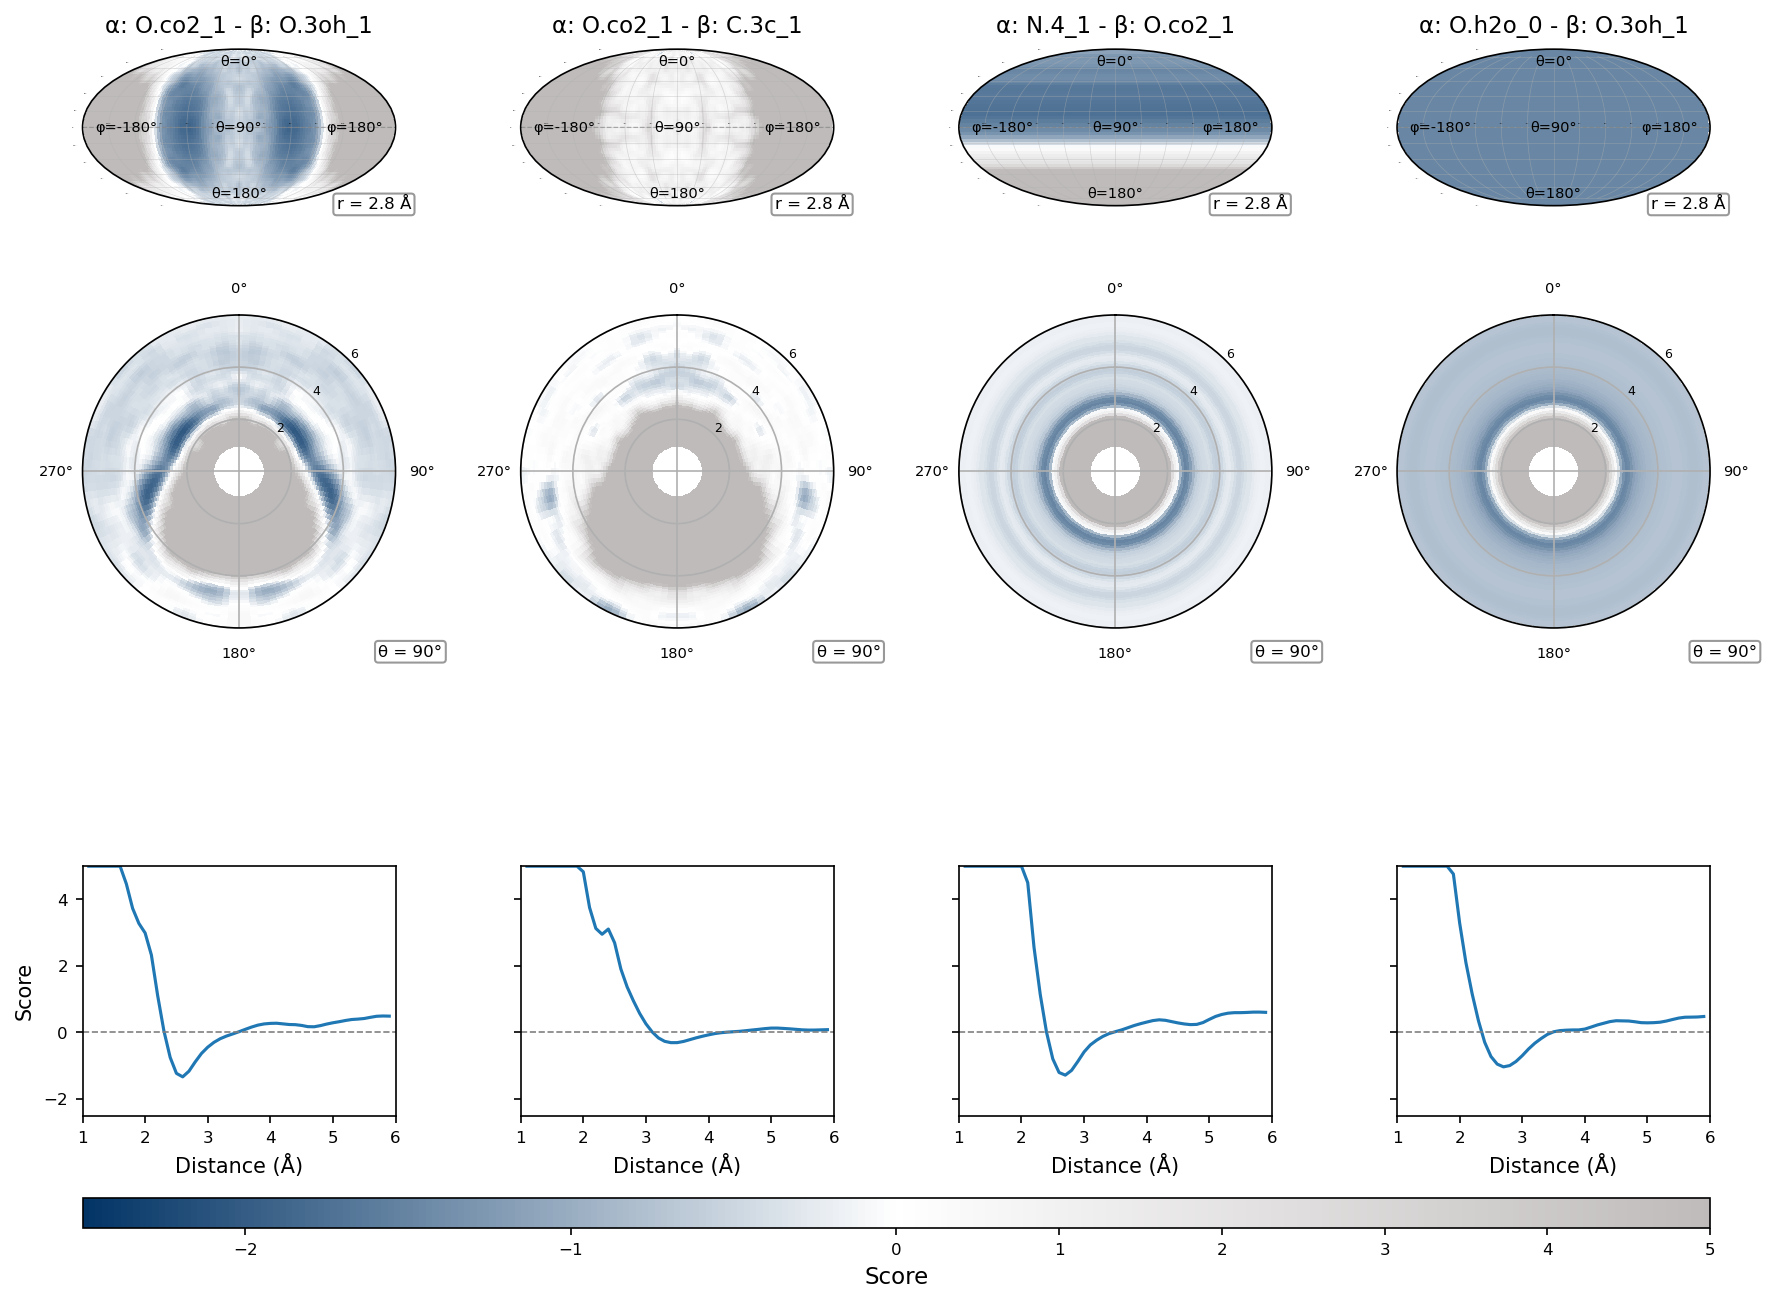

In [5]:
print(prot_types_list)
print(ligand_types_list)

p_type_list = ['O.co2_1', 'O.co2_1', 'N.4_1', 'O.h2o_0']
l_type_list = ['O.3oh_1', 'C.3c_1', 'O.co2_1', 'O.3oh_1']
distance_list = [2.8, 2.8, 2.8, 2.8]
plot_anisotropy(p_type_list, l_type_list, distance_list)